In [1]:
# ==========================================
# ENVIRONMENT SETUP
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import random
from timeit import default_timer as timer
from pathlib import Path

# PyTorch imports for later phases
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2


In [2]:
# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 0.1
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [3]:
def set_seeds(seed=42):
    """Sets seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # The following settings are for absolute determinism but might slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call the function at the start of your experiments
set_seeds(SEED)

In [4]:

# Move the uploaded Kaggle key to the secure folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/ 2>/dev/null
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null

print("Downloading dataset from Kaggle...")
# Download the zip file directly
!kaggle datasets download -d qingyi/wm811k-wafer-map -q
print("Download complete!")

Dataset URL: https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map
License(s): CC0-1.0
Download complete!


In [5]:
# ==========================================
# CELL 2: EXTRACTION & FILE SETUP
# ==========================================
print("Extracting dataset...")
# Moved the flags (-q for quiet, -o for overwrite) before the filename
!unzip -qo wm811k-wafer-map.zip
print("Extraction complete!\n")

# Verify the file size (Should be ~1.0G)
!ls -lh LSWMD.pkl

# Assign the path to a variable for the rest of the notebook
dataset_path = '/content/LSWMD.pkl'
print(f"\nDataset path successfully assigned to variable: dataset_path = '{dataset_path}'")

Extracting dataset...
Extraction complete!

-rw-r--r-- 1 root root 2.0G Sep 27  2019 LSWMD.pkl

Dataset path successfully assigned to variable: dataset_path = '/content/LSWMD.pkl'


In [6]:
print("Loading 2GB dataset into Pandas... (This takes ~30 seconds)")
data_wafer = pd.read_pickle(dataset_path)

Loading 2GB dataset into Pandas... (This takes ~30 seconds)


### 1. DATA EXPLORATION

In [7]:

print("SHAPE:", data_wafer.shape)

print("COLUMN NAMES:", data_wafer.columns.tolist())

print("\n=== DATASET INFO ===")
data_wafer.info()

print("\n=== RANDOM 5 ROWS ===")
display(data_wafer.sample(5))

SHAPE: (811457, 6)
COLUMN NAMES: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB

=== RANDOM 5 ROWS ===


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
552336,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...",712.0,lot34696,6.0,[],[]
24803,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",776.0,lot2724,2.0,[],[]
426607,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6052.0,lot25655,12.0,[],[]
722885,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1,...",518.0,lot43945,20.0,[[Test]],[[none]]
192536,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6328.0,lot12178,18.0,[],[]


 INVESTIGATING THE RAW WM-811K DATASET

--- PROBLEM 1: MISSING LABELS ---
Total Wafers in Dataset: 811,457
Wafers WITH labels:      172,950
Wafers WITHOUT labels:   638,507
Percentage of Useless Data: 78.7%

>> CNNs require ground-truth labels to learn. If we feed empty [] labels into PyTorch, the loss function will crash.

--- PROBLEM 2: NESTED LIST FORMATTING ---
Look closely at how the strings are trapped inside double brackets:


,trianTestLabel,failureType
0,[[Training]],[[none]]
1,[[Training]],[[none]]
2,[[Training]],[[none]]


>> PyTorch expects simple integers (e.g., 0, 1, 2) for classification. We cannot pass [['none']] or [['Edge-Loc']] into a tensor.

--- PROBLEM 3: INCONSISTENT MATRIX SIZES ---
Wafer A Matrix Shape: (45, 48)
Wafer B Matrix Shape: (26, 30)
>> A standard Convolutional Neural Network requires a strictly fixed input size (like 64x64 or 224x224). Passing dynamic shapes will instantly trigger a Matrix Multiplication error.



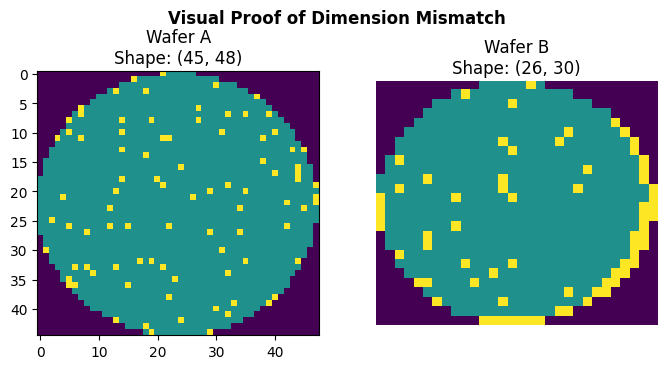


--- PROBLEM 4: EXTREME CLASS IMBALANCE ---
Defect Count Breakdown:
failureType
[['none']]         147431
[['Edge-Ring']]      9680
[['Edge-Loc']]       5189
[['Center']]         4294
[['Loc']]            3593
[['Scratch']]        1193
[['Random']]          866
[['Donut']]           555
[['Near-full']]       149

>> The model will see ~147,000 perfect wafers, but only a few hundred of certain defects. It might achieve 85% accuracy by simply guessing 'none' every time and ignoring the actual defects.


/tmp/ipykernel_1519/2441006803.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')


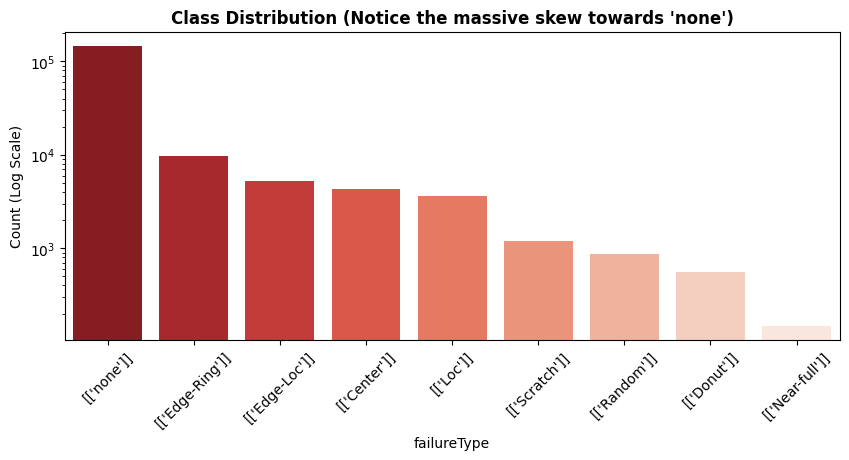

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("==================================================")
print(" INVESTIGATING THE RAW WM-811K DATASET")
print("==================================================\n")

# ---------------------------------------------------------
# PROBLEM 1: THE UNLABELED DATA CRISIS
# ---------------------------------------------------------
print("--- PROBLEM 1: MISSING LABELS ---")
total_wafers = len(data_wafer)
# Count how many rows have empty brackets []
empty_labels = data_wafer['failureType'].apply(lambda x: len(x) == 0).sum()
labeled_wafers = total_wafers - empty_labels

print(f"Total Wafers in Dataset: {total_wafers:,}")
print(f"Wafers WITH labels:      {labeled_wafers:,}")
print(f"Wafers WITHOUT labels:   {empty_labels:,}")
print(f"Percentage of Useless Data: {(empty_labels/total_wafers)*100:.1f}%\n")
print(">> CNNs require ground-truth labels to learn. If we feed empty [] labels into PyTorch, the loss function will crash.\n")

# ---------------------------------------------------------
# PROBLEM 2: THE NESTED LIST FORMATTING
# ---------------------------------------------------------
print("--- PROBLEM 2: NESTED LIST FORMATTING ---")
print("Look closely at how the strings are trapped inside double brackets:")
display(data_wafer[['trianTestLabel', 'failureType']].dropna().head(3))
print(">> PyTorch expects simple integers (e.g., 0, 1, 2) for classification. We cannot pass [['none']] or [['Edge-Loc']] into a tensor.\n")

# ---------------------------------------------------------
# PROBLEM 3: INCONSISTENT SPATIAL DIMENSIONS
# ---------------------------------------------------------
print("--- PROBLEM 3: INCONSISTENT MATRIX SIZES ---")
# Let's grab two random wafers from different manufacturing lots
wafer_A = data_wafer['waferMap'].iloc[0]
wafer_B = data_wafer['waferMap'].iloc[-2] # Grab one from the very end of the file

print(f"Wafer A Matrix Shape: {wafer_A.shape}")
print(f"Wafer B Matrix Shape: {wafer_B.shape}")
print(">> A standard Convolutional Neural Network requires a strictly fixed input size (like 64x64 or 224x224). Passing dynamic shapes will instantly trigger a Matrix Multiplication error.\n")

# Plot the dimension mismatch
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(wafer_A, cmap='viridis')
axes[0].set_title(f"Wafer A\nShape: {wafer_A.shape}")
axes[1].imshow(wafer_B, cmap='viridis')
axes[1].set_title(f"Wafer B\nShape: {wafer_B.shape}")
plt.suptitle("Visual Proof of Dimension Mismatch", fontweight='bold')
plt.axis(False)
plt.show()

# ---------------------------------------------------------
# PROBLEM 4: EXTREME CLASS IMBALANCE
# ---------------------------------------------------------
print("\n--- PROBLEM 4: EXTREME CLASS IMBALANCE ---")
# Extract labels temporarily just to plot them
temp_labels = data_wafer[data_wafer['failureType'].apply(lambda x: len(x) > 0)]['failureType'].apply(lambda x: x).astype(str)
label_counts = temp_labels.value_counts()

print("Defect Count Breakdown:")
print(label_counts.to_string())
print("\n>> The model will see ~147,000 perfect wafers, but only a few hundred of certain defects. It might achieve 85% accuracy by simply guessing 'none' every time and ignoring the actual defects.")

# Plot the imbalance
plt.figure(figsize=(10, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')
plt.title("Class Distribution (Notice the massive skew towards 'none')", fontweight='bold')
plt.yscale('log') # Use a logarithmic scale so we can actually see the smaller columns!
plt.xticks(rotation=45)
plt.ylabel("Count (Log Scale)")
plt.show()

### Perparing DATASET

In [9]:
print("Building global answer key...")

# 1. Clean the master dataframe FIRST
df_clean = data_wafer[data_wafer['failureType'].apply(lambda x: len(x) > 0)].reset_index(drop=True)
df_clean['clean_label'] = df_clean['failureType'].apply(lambda x: x).astype(str)

# 2. CREATE THE MASTER MAPPING ONCE
global_classes = df_clean['clean_label'].unique().tolist()
master_class_to_idx = {cls_name: idx for idx, cls_name in enumerate(global_classes)}

print(f"Master Mapping Locked: {master_class_to_idx}\n")

Building global answer key...
Master Mapping Locked: {"[['none']]": 0, "[['Loc']]": 1, "[['Edge-Loc']]": 2, "[['Center']]": 3, "[['Edge-Ring']]": 4, "[['Scratch']]": 5, "[['Random']]": 6, "[['Near-full']]": 7, "[['Donut']]": 8}



In [10]:
# ==========================================
# REPAIRED PYTORCH DATA PIPELINE
# ==========================================
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import numpy as np
from sklearn.model_selection import train_test_split

# 3. THE REPAIRED DATASET CLASS
class WaferDataset(Dataset):
    def __init__(self, dataframe, class_map, transform=None):
        self.df = dataframe.reset_index(drop=True)

        # Use the master map instead of generating a new one!
        self.class_to_idx = class_map
        self.classes = list(class_map.keys())
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wafer_matrix = self.df['waferMap'].iloc[idx]
        label_str = self.df['clean_label'].iloc[idx]

        label_idx = self.class_to_idx[label_str]
        wafer_img = np.expand_dims(wafer_matrix, axis=-1).astype(np.float32)

        if self.transform:
            wafer_img = self.transform(wafer_img)

        return wafer_img, torch.tensor(label_idx, dtype=torch.long)

# 4. TRAIN/TEST SPLIT
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42, stratify=df_clean['clean_label'])

# 5. TRANSFORMS
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((64, 64), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True)
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((64, 64), antialias=True),
    v2.ToDtype(torch.float32, scale=True)
])

# 6. INSTANTIATE WITH THE MASTER MAP
train_dataset = WaferDataset(dataframe=train_df, class_map=master_class_to_idx, transform=train_transforms)
test_dataset = WaferDataset(dataframe=test_df, class_map=master_class_to_idx, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders Successfully Repaired!")

DataLoaders Successfully Repaired!


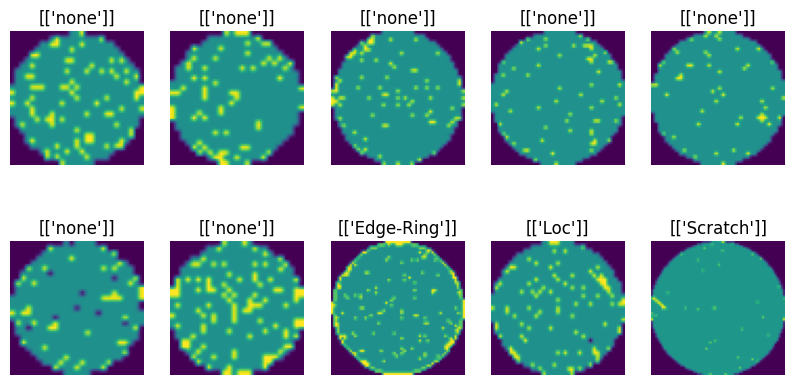

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.axis(False)
    plt.title(train_dataset.classes[labels[i]])
    plt.imshow(images[i].permute(1, 2, 0), cmap='viridis')

### CNN Model

In [12]:
# ==========================================
# 5. ARCHITECTING THE NEURAL NETWORK
# ==========================================
import torch.nn as nn
import torch.nn.functional as F

class WaferCNN(nn.Module):
    def __init__(self, num_classes):
        super(WaferCNN, self).__init__()

        # --- STAGE 1: FEATURE EXTRACTION (The Convolutional Blocks) ---

        # Block 1: Looks for basic edges and lines
        # Input: [Batch, 1, 64, 64] -> Output: [Batch, 16, 32, 32]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Looks for curves and simple shapes
        # Input: [Batch, 16, 32, 32] -> Output: [Batch, 32, 16, 16]
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Block 3: Looks for complex defect patterns (like Donuts or Scratches)
        # Input: [Batch, 32, 16, 16] -> Output: [Batch, 64, 8, 8]
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # --- STAGE 2: CLASSIFICATION (The Fully Connected Layers) ---

        # Flattening the 3D tensor into a 1D array for the dense layers
        # Math: 64 channels * 8 height * 8 width = 4096 flat connections
        self.fc1 = nn.Linear(64 * 8 * 8, 128)

        # Dropout randomly turns off 50% of the neurons during training.
        # This prevents the network from memorizing the massive 'none' class!
        self.dropout = nn.Dropout(0.5)

        # The final output layer: 128 neurons down to the 9 defect classes
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Pass data through Convolutional blocks with ReLU activation
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the matrix into a single vector
        x = torch.flatten(x, 1)

        # Pass through Dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### Functions for training, testing and metrics to evaluate the model

In [13]:
def print_time (start: float,
               end: float,
               device: torch.device = 'cpu',
               time_msg = "calculated time"):
  time = end - start
  print(f"{time_msg} on {device}: {time:.3f} sec")
  return time

In [14]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = 'cpu'):
  """Performs a training with model trying to learn on data_loader."""
  train_loss = 0
  train_acc = 0

  # model in training mode
  model.train()

  # loop through the training batches
  for batch, (X, y) in enumerate(data_loader):
    # Put data on target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass (outputs the raw logits from the model)
    y_pred = model(X)

    # 2. Calculate loss and accuracy (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss
    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1)) # go from logits -> prediction labels

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step (update the model's parameters once *per batch*)
    optimizer.step()

  # Divide total train loss and acc by length of train dataloader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [15]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = 'cpu'):
  """Performs a testing loop step on model going over data_loader."""
  test_loss = 0
  test_acc = 0

  # model in eval mode
  model.eval()

  # Turn on inference mode context manager
  with torch.inference_mode():
    for X, y in data_loader:
      # Send the data to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass (outputs raw logits)
      test_pred = model(X)

      # 2. Calculuate the loss/acc
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1)) # go from logits -> prediction labels

    # Adjust metrics and print out
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n")

In [16]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               class_names: list,          # <--- Added to make the chart readable
               confmatrix_en: bool = True, # <--- Fixed to be a real boolean
               device: torch.device = 'cpu'):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss = 0
  acc = 0

  y_pred_list = []
  y_true_list = [] # <--- We need the answer key to grade the test!

  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader, desc="Evaluating"):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # Make predictions
      y_logits = model(X)
      y_pred = y_logits.argmax(dim=1)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_logits, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred)

      # Save BOTH the predictions and the true answers to CPU memory
      y_pred_list.append(y_pred.cpu())
      y_true_list.append(y.cpu())

    # Scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  # Concatenate lists into solid tensors
  y_pred_tensor = torch.cat(y_pred_list)
  y_true_tensor = torch.cat(y_true_list)

  # ==========================================
  # PLOT THE CONFUSION MATRIX IF ENABLED
  # ==========================================
  if confmatrix_en:
      print("\n=== CLASSIFICATION REPORT ===")
      print(classification_report(y_true_tensor.numpy(), y_pred_tensor.numpy(), target_names=class_names, zero_division=0))

      print("\nRendering Confusion Matrix...")
      cm = confusion_matrix(y_true_tensor.numpy(), y_pred_tensor.numpy())

      plt.figure(figsize=(10, 8))
      # We use LogNorm() because the 'none' class is so massive it hides the other colors
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                  xticklabels=class_names, yticklabels=class_names,
                  norm=plt.matplotlib.colors.LogNorm())

      plt.title("Wafer Defect Confusion Matrix", fontsize=14, fontweight='bold')
      plt.ylabel('Actual True Defect')
      plt.xlabel('Neural Network Prediction')
      plt.xticks(rotation=45)
      plt.tight_layout()
      plt.show()

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

In [18]:
# ==========================================
# MODEL SAVING AND LOADING
# ==========================================

def save_model(model: torch.nn.Module, target_dir: str, model_name: str):
    """
    Saves a PyTorch model's state_dict to a specified directory.
    """
    # 1. Create target directory safely
    target_dir_path = Path(target_dir)
    target_dir_path.mkdir(parents=True, exist_ok=True)

    # 2. Create model save path
    assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
    model_save_path = target_dir_path / model_name

    # 3. Save the model state_dict
    print(f"[INFO] Saving model weights to: {model_save_path}")
    torch.save(obj=model.state_dict(), f=model_save_path)


def load_model(empty_model: torch.nn.Module, model_path: str, device: torch.device):
    """
    Loads saved weights into an empty PyTorch model architecture.
    """
    model_path = Path(model_path)
    assert model_path.exists(), f"Error: Cannot find {model_path}"

    print(f"[INFO] Loading model weights from: {model_path}")

    # Load the state_dict into the provided empty architecture
    # map_location ensures it loads safely whether you are using CPU or GPU
    empty_model.load_state_dict(torch.load(f=model_path, map_location=device))

    # Move the fully loaded model to the target device
    return empty_model.to(device)

##**Main function to train, test and evaluate the model**

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Calculating mathematical class weights to fight imbalance...")

# 1. Get the exact class names in the correct order
class_names = train_dataset.classes
y_train = train_df['clean_label'].values

# 2. Let scikit-learn calculate the optimal penalty weights for each class
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.array(class_names),
                                     y=y_train)

# 3. Convert the weights to a PyTorch Tensor and move them to your GPU
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Weights calculated! Rare classes now have massive penalties.")

Calculating mathematical class weights to fight imbalance...
Weights calculated! Rare classes now have massive penalties.


In [21]:
set_seeds(SEED)

print("Constructing the CNN Architecture...")
CNN_model_1 = WaferCNN(num_classes=len(train_dataset.classes)).to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.Adam(params=CNN_model_1.parameters(), lr=0.001)


epochs = 5
start_time = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")

  ## Training
  train_step(model=CNN_model_1,
             data_loader=train_loader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  ## Testing
  test_step(model=CNN_model_1,
            data_loader=test_loader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

end_time = timer()
runtime_model_0 = print_time(start = start_time,
           end = end_time,
           device = str(next(CNN_model_1.parameters()).device),
                     time_msg = "total RunTime")

Constructing the CNN Architecture...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.17811 | Train acc: 62.83%
Test loss: 0.73959 | Test acc: 78.23%

Epoch: 1
-------
Train loss: 0.78127 | Train acc: 77.65%
Test loss: 0.57739 | Test acc: 83.87%

Epoch: 2
-------
Train loss: 0.67252 | Train acc: 80.80%
Test loss: 0.54151 | Test acc: 82.78%

Epoch: 3
-------
Train loss: 0.61694 | Train acc: 82.43%
Test loss: 0.48685 | Test acc: 92.69%

Epoch: 4
-------
Train loss: 0.56537 | Train acc: 84.20%
Test loss: 0.43817 | Test acc: 87.65%

total RunTime on cuda:0: 448.991 sec


In [22]:
# Save the model
from google.colab import drive

drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Wafer_proj/models"

save_model(model=CNN_model_1,
           target_dir=save_path,
           model_name="WaferCNN_v1.pth")

Mounted at /content/drive
[INFO] Saving model weights to: /content/drive/MyDrive/Wafer_proj/models/WaferCNN_v1.pth


In [23]:
# Load the model
from google.colab import drive

drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Wafer_proj/models"

loaded_WaferCNN = WaferCNN(num_classes=len(train_dataset.classes))

loaded_WaferCNN = load_model(empty_model=loaded_WaferCNN,
                             model_path=f"{save_path}/WaferCNN_v1.pth",
                             device=device)

print("Model successfully loaded and ready for inference!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Loading model weights from: /content/drive/MyDrive/Wafer_proj/models/WaferCNN_v1.pth
Model successfully loaded and ready for inference!


Evaluating:   0%|          | 0/541 [00:00<?, ?it/s]


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      'none'       1.00      0.88      0.93     29486
       'Loc'       0.56      0.70      0.62       718
  'Edge-Loc'       0.49      0.84      0.62      1038
    'Center'       0.69      0.96      0.80       859
 'Edge-Ring'       0.95      0.95      0.95      1936
   'Scratch'       0.06      0.60      0.11       239
    'Random'       0.71      0.90      0.79       173
 'Near-full'       0.88      0.77      0.82        30
     'Donut'       0.64      0.93      0.75       111

    accuracy                           0.88     34590
   macro avg       0.66      0.84      0.71     34590
weighted avg       0.95      0.88      0.91     34590


Rendering Confusion Matrix...


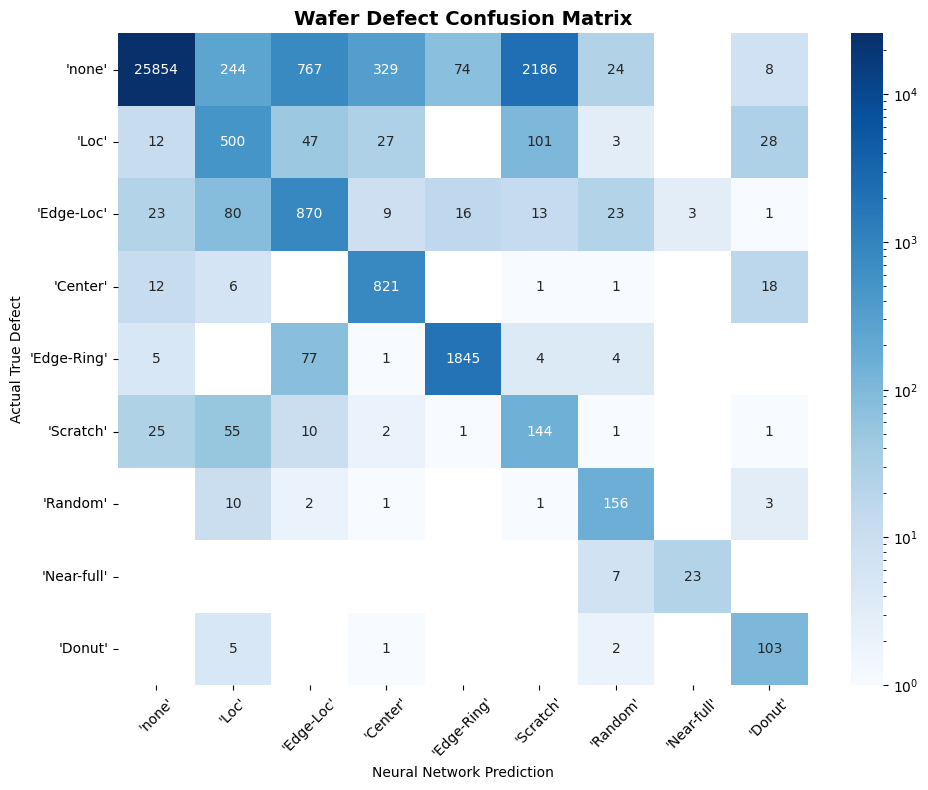

{'model_name': 'WaferCNN',
 'model_loss': 0.43817001581192017,
 'model_acc': 87.6494146642021}

In [25]:
# We use string slicing [2:-2] to remove the [[' and ']] from each class name.
cleaned_class_names = [name[2:-2] for name in train_dataset.classes]

eval_results = eval_model(model=loaded_WaferCNN,
                          data_loader=test_loader,
                          loss_fn=loss_fn,
                          accuracy_fn=accuracy_fn,
                          class_names=cleaned_class_names,
                          confmatrix_en=True,
                          device=device)

eval_results

In [26]:
# ==========================================
# 10. ARCHITECTING MODEL 2: RESNET-18
# ==========================================
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torch.nn as nn

class WaferResNet(nn.Module):
    def __init__(self, num_classes):
        super(WaferResNet, self).__init__()

        # 1. Download the pre-trained ResNet-18 architecture
        # These weights already know how to find incredibly complex geometric patterns
        self.resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # 2. SURGERY: Modify the Input Layer
        # We replace the very first layer to accept 1 channel instead of 3
        self.resnet.conv1 = nn.Conv2d(in_channels=1,
                                      out_channels=64,
                                      kernel_size=7,
                                      stride=2,
                                      padding=3,
                                      bias=False)

        # 3. SURGERY: Modify the Output Layer
        # We replace the final Fully Connected layer to output our 9 defect classes
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        # The data just flows cleanly through the modified ResNet
        return self.resnet(x)

In [27]:
set_seeds(SEED)

print("Constructing the CNN Architecture...")
CNN_model_2 = WaferResNet(num_classes=len(train_dataset.classes)).to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.Adam(params=CNN_model_2.parameters(), lr=0.001)


epochs = 5
start_time = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")

  ## Training
  train_step(model=CNN_model_2,
             data_loader=train_loader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  ## Testing
  test_step(model=CNN_model_2,
            data_loader=test_loader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

end_time = timer()
runtime_model_2 = print_time(start = start_time,
                             end = end_time,
           device = str(next(CNN_model_2.parameters()).device),
                     time_msg = "total RunTime")

Constructing the CNN Architecture...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.96712 | Train acc: 75.36%
Test loss: 0.76368 | Test acc: 59.35%

Epoch: 1
-------
Train loss: 0.66003 | Train acc: 80.42%
Test loss: 0.61720 | Test acc: 82.81%

Epoch: 2
-------
Train loss: 0.50267 | Train acc: 84.44%
Test loss: 0.60803 | Test acc: 90.72%

Epoch: 3
-------
Train loss: 0.46671 | Train acc: 84.55%
Test loss: 0.52915 | Test acc: 88.01%

Epoch: 4
-------
Train loss: 0.39632 | Train acc: 87.66%
Test loss: 0.43881 | Test acc: 95.18%

total RunTime on cuda:0: 610.668 sec


In [28]:
# Save the model
from google.colab import drive

drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Wafer_proj/models"

save_model(model=CNN_model_2,
           target_dir=save_path,
           model_name="WaferCNN_v0.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Saving model weights to: /content/drive/MyDrive/Wafer_proj/models/WaferCNN_v0.pth


In [32]:
# Load the model
from google.colab import drive

drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Wafer_proj/models"

loaded_WaferCNN_v0 = WaferResNet(num_classes=len(train_dataset.classes))

loaded_WaferCNN_v0 = load_model(empty_model=loaded_WaferCNN_v0,
                             model_path=f"{save_path}/WaferCNN_v0.pth",
                             device=device)

print("Model res successfully loaded and ready for inference!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Loading model weights from: /content/drive/MyDrive/Wafer_proj/models/WaferCNN_v0.pth
Model res successfully loaded and ready for inference!


Evaluating:   0%|          | 0/541 [00:00<?, ?it/s]


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      'none'       0.99      0.97      0.98     29486
       'Loc'       0.77      0.61      0.68       718
  'Edge-Loc'       0.70      0.84      0.76      1038
    'Center'       0.93      0.90      0.91       859
 'Edge-Ring'       0.90      0.97      0.94      1936
   'Scratch'       0.24      0.74      0.36       239
    'Random'       0.77      0.81      0.79       173
 'Near-full'       0.73      1.00      0.85        30
     'Donut'       0.73      0.88      0.80       111

    accuracy                           0.95     34590
   macro avg       0.75      0.86      0.79     34590
weighted avg       0.96      0.95      0.96     34590


Rendering Confusion Matrix...


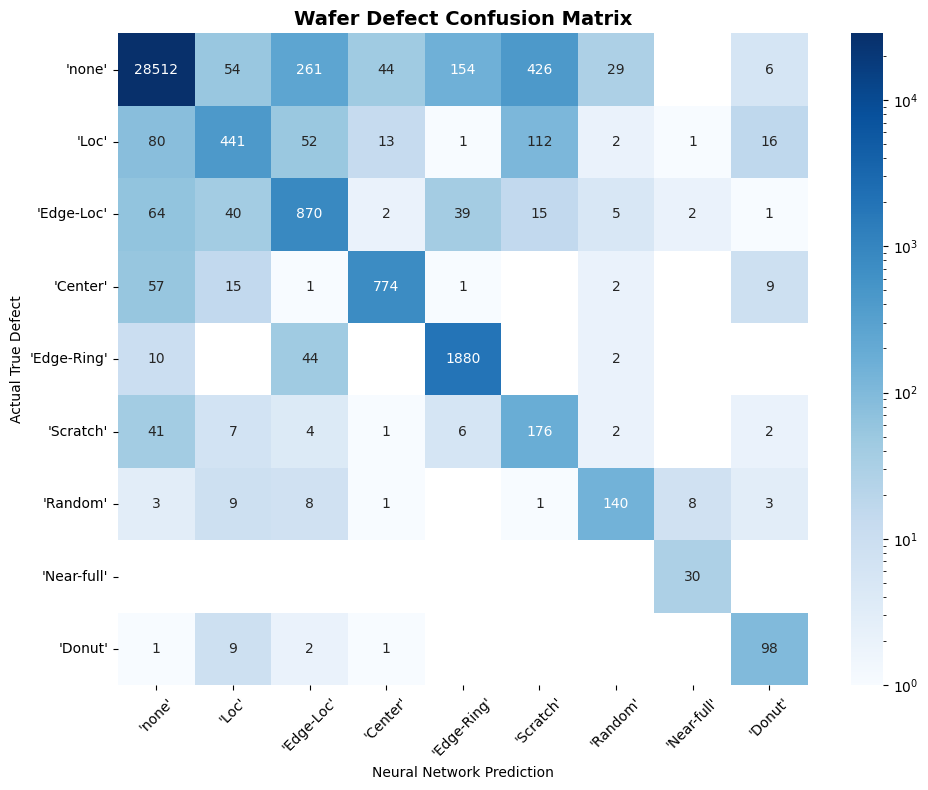

{'model_name': 'WaferResNet',
 'model_loss': 0.4388100504875183,
 'model_acc': 95.17637091805298}

In [33]:
cleaned_class_names = [name[2:-2] for name in train_dataset.classes]

eval_results_2 = eval_model(model=loaded_WaferCNN_v0,
                          data_loader=test_loader,
                          loss_fn=loss_fn,
                          accuracy_fn=accuracy_fn,
                          class_names=cleaned_class_names,
                          confmatrix_en=True,
                          device=device)

eval_results_2

## Improve the Model

In [34]:

import torch.nn as nn
import torch.nn.functional as F
import torch

# --- COMPONENT 1: THE CUSTOM RESIDUAL BLOCK ---
# We build our own "bridge" module so we never lose thin lines
class CustomResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(CustomResBlock, self).__init__()

        # The Main Path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels) # Stabilizes the math!
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # The Bridge Path (Skip Connection)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            # If the image shrinks, the bridge has to shrink with it to match dimensions
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # ADD THE BRIDGE BEFORE THE FINAL ACTIVATION
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# --- COMPONENT 2: THE MAIN NETWORK ---
class WaferCNN_v2(nn.Module):
    def __init__(self, num_classes):
        super(WaferCNN_v2, self).__init__()

        # Initial Edge Detection
        self.prep = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # The deep feature extractors (Expanding from 32 -> 64 -> 128 -> 256 filters)
        self.layer1 = CustomResBlock(32, 64, stride=2)   # Shrinks image to 32x32
        self.layer2 = CustomResBlock(64, 128, stride=2)  # Shrinks image to 16x16
        self.layer3 = CustomResBlock(128, 256, stride=2) # Shrinks image to 8x8

        # Gracefully squashes the remaining spatial dimensions into a 1x1 vector
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # The Classifier
        self.fc = nn.Sequential(
            nn.Dropout(0.5), # Still need dropout to fight the 85% imbalance!
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.pool(x)
        x = torch.flatten(x, 1) # Flatten for the dense layer
        x = self.fc(x)
        return x

In [35]:
set_seeds(SEED)

print("Constructing the CNN Architecture...")
CNN_model_3 = WaferCNN_v2(num_classes=len(train_dataset.classes)).to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.Adam(params=CNN_model_3.parameters(), lr=0.001)


epochs = 5
start_time = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")

  ## Training
  train_step(model=CNN_model_3,
             data_loader=train_loader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  ## Testing
  test_step(model=CNN_model_3,
            data_loader=test_loader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

end_time = timer()
runtime_model_3 = print_time(start = start_time,
                             end = end_time,
           device = str(next(CNN_model_3.parameters()).device),
                     time_msg = "total RunTime")

Constructing the CNN Architecture...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.04665 | Train acc: 71.87%
Test loss: 1.97022 | Test acc: 8.93%

Epoch: 1
-------
Train loss: 0.71802 | Train acc: 83.92%
Test loss: 0.63978 | Test acc: 90.75%

Epoch: 2
-------
Train loss: 0.56851 | Train acc: 88.54%
Test loss: 0.46333 | Test acc: 87.55%

Epoch: 3
-------
Train loss: 0.49225 | Train acc: 90.72%
Test loss: 1.72194 | Test acc: 55.35%

Epoch: 4
-------
Train loss: 0.42895 | Train acc: 91.82%
Test loss: 0.38855 | Test acc: 92.37%

total RunTime on cuda:0: 509.730 sec


In [36]:
# Save the model
from google.colab import drive

drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Wafer_proj/models"

save_model(model=CNN_model_3,
           target_dir=save_path,
           model_name="WaferCNN_v2.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Saving model weights to: /content/drive/MyDrive/Wafer_proj/models/WaferCNN_v2.pth


In [37]:
# Load the model
from google.colab import drive

drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Wafer_proj/models"

loaded_WaferCNN_v2 = WaferCNN_v2(num_classes=len(train_dataset.classes))

loaded_WaferCNN_v2 = load_model(empty_model=loaded_WaferCNN_v2,
                             model_path=f"{save_path}/WaferCNN_v2.pth",
                             device=device)

print("Model successfully loaded and ready for inference!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Loading model weights from: /content/drive/MyDrive/Wafer_proj/models/WaferCNN_v2.pth
Model successfully loaded and ready for inference!


Evaluating:   0%|          | 0/541 [00:00<?, ?it/s]


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      'none'       1.00      0.94      0.97     29486
       'Loc'       0.44      0.74      0.55       718
  'Edge-Loc'       0.54      0.81      0.65      1038
    'Center'       0.75      0.94      0.83       859
 'Edge-Ring'       1.00      0.88      0.93      1936
   'Scratch'       0.23      0.85      0.36       239
    'Random'       0.63      0.89      0.74       173
 'Near-full'       0.58      1.00      0.73        30
     'Donut'       0.64      0.80      0.71       111

    accuracy                           0.92     34590
   macro avg       0.64      0.87      0.72     34590
weighted avg       0.96      0.92      0.94     34590


Rendering Confusion Matrix...


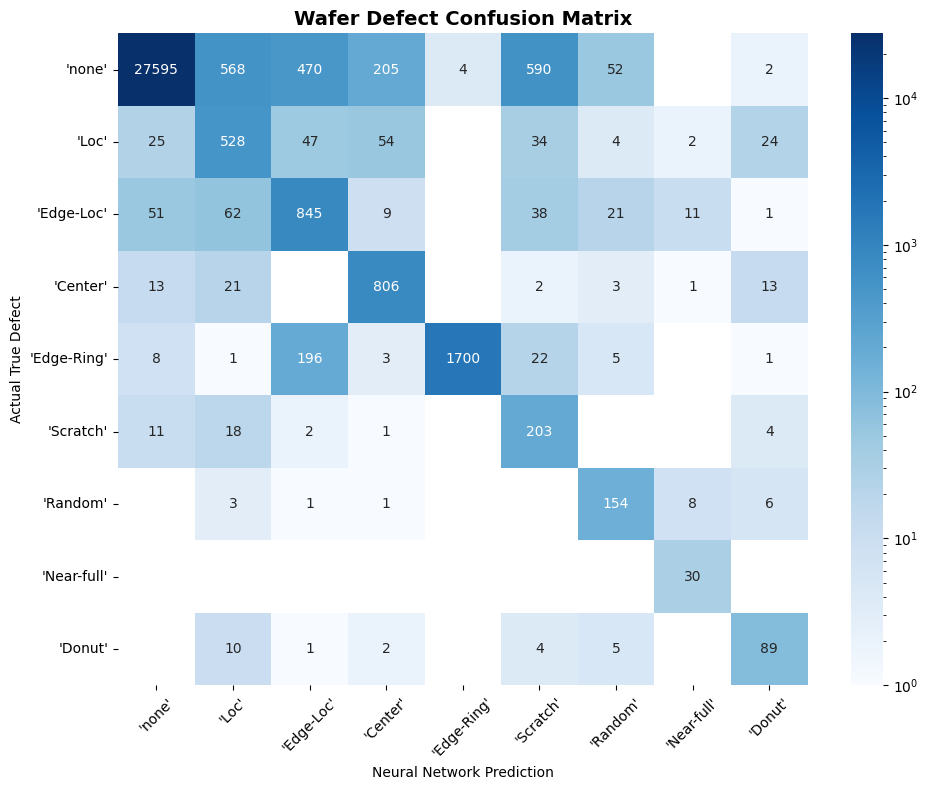

{'model_name': 'WaferCNN_v2',
 'model_loss': 0.38854843378067017,
 'model_acc': 92.3654112754159}

In [38]:
eval_results_3 = eval_model(model=loaded_WaferCNN_v2,
                          data_loader=test_loader,
                          loss_fn=loss_fn,
                          accuracy_fn=accuracy_fn,
                          class_names=cleaned_class_names,
                          confmatrix_en=True,
                          device=device)

eval_results_3

🏭 Assembly Line AI Scanner Initialized...



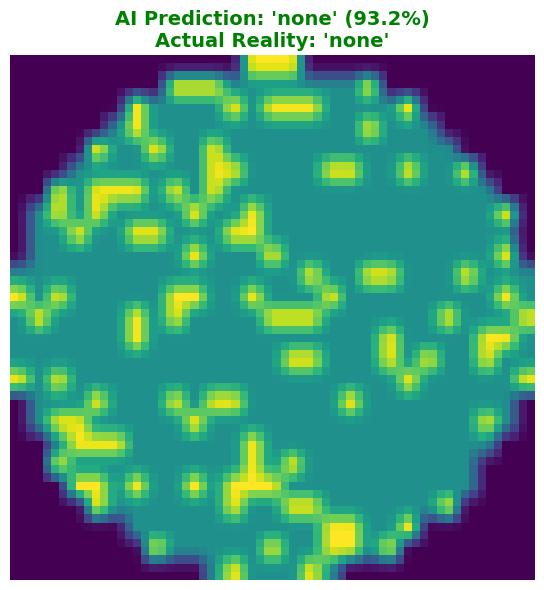

In [44]:
# ==========================================
# 14. REAL-TIME INFERENCE (FACTORY FLOOR)
# ==========================================
import matplotlib.pyplot as plt
import random
import torch
import torch.nn.functional as F
cleaned_class_names = [name[2:-2] for name in train_dataset.classes]

def inspect_random_wafer(model, dataset, class_names, device):
    # 1. Put the model in evaluation mode (No training allowed!)
    model.eval()

    # 2. Pick a random, unseen wafer from the test dataset
    random_idx = random.randint(0, len(dataset) - 1)
    wafer_img, true_label_idx = dataset[random_idx]

    # 3. Format for the AI: Add a fake "batch" dimension ->
    wafer_input = wafer_img.unsqueeze(0).to(device)

    # 4. PERFORM INFERENCE (The actual AI diagnosis)
    with torch.inference_mode():
        raw_logits = model(wafer_input)

        # Convert the raw mathematical outputs into clean percentages (0 to 100%)
        probabilities = F.softmax(raw_logits, dim=1)

        # Find the specific class the AI is most confident in
        predicted_idx = torch.argmax(probabilities, dim=1).item()

        # Extract the human-readable strings and the confidence score
        predicted_label = class_names[predicted_idx]
        predicted_label = predicted_label[2:-2]

        true_label = class_names[true_label_idx.item()]
        true_label = true_label[2:-2]

        confidence = probabilities[0, predicted_idx].item() * 100

    # 5. VISUALIZE THE VERDICT
    plt.figure(figsize=(6, 6))

    # Squeeze out the channel dimension so matplotlib can draw a 2D picture
    img_to_plot = wafer_img.squeeze().numpy()

    # We use 'viridis' color map because it highlights the defect geometry beautifully
    plt.imshow(img_to_plot, cmap='viridis')

    # Logic to paint the text Green if the AI is right, and Red if it's wrong
    title_color = "green" if predicted_label == true_label else "red"

    plt.title(f"AI Prediction: {predicted_label} ({confidence:.1f}%)\nActual Reality: {true_label}",
              color=title_color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- RUN THE DIAGNOSIS ---
print("🏭 Assembly Line AI Scanner Initialized...\n")

# Run the function!
inspect_random_wafer(model=loaded_WaferCNN_v2,
                     dataset=test_dataset,
                     class_names=train_dataset.classes,
                     device=device)

🏭 Assembly Line AI Scanner (10-Wafer Batch) Initialized...



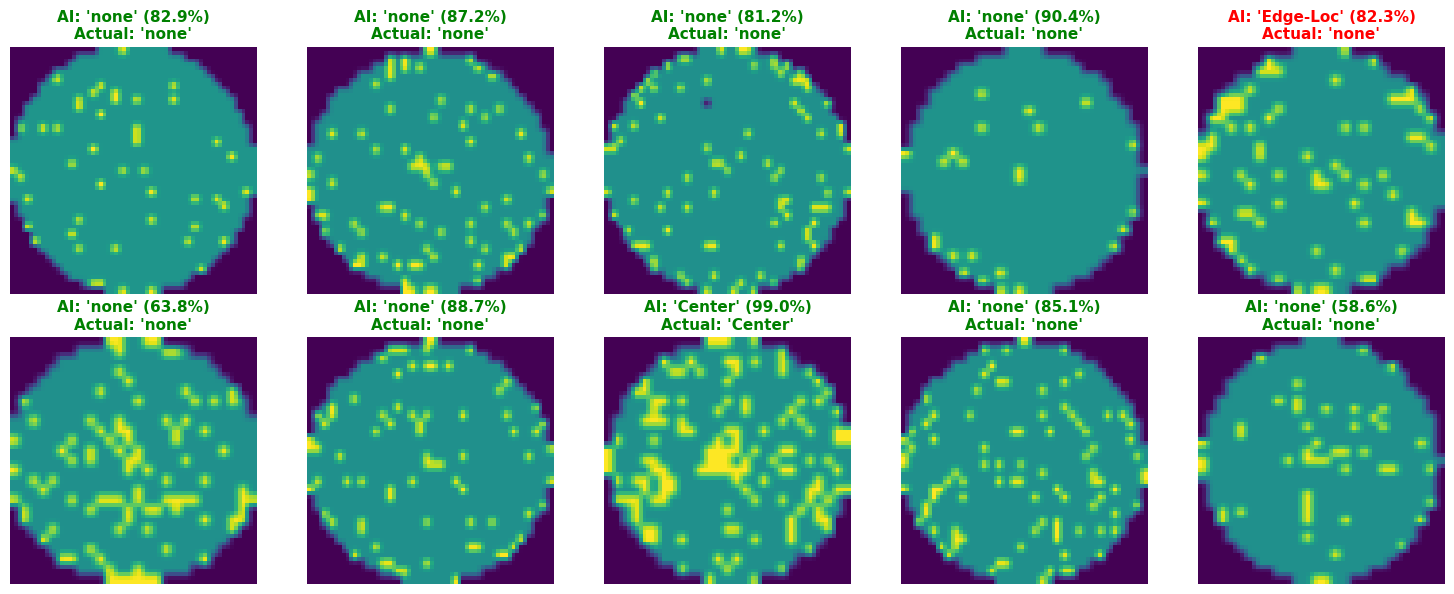

In [53]:
# ==========================================
# 14. REAL-TIME BATCH INFERENCE (SIMPLIFIED)
# ==========================================
import matplotlib.pyplot as plt
import random
import torch
import torch.nn.functional as F

# Clean the names once outside the function
cleaned_class_names = [name[2:-2] for name in train_dataset.classes]

def inspect_wafer_batch(model, dataset, class_names, device):
    model.eval()

    # 1. Grab 10 random wafers and their true labels
    indices = random.sample(range(len(dataset)), 10)
    wafers_and_labels = [dataset[i] for i in indices]

    # Separate wafers and true labels, ensuring true_labels are scalars
    wafers = [item[0] for item in wafers_and_labels] # Extract only the image tensors
    true_labels = [item[1].item() for item in wafers_and_labels] # Extract the scalar label

    # 2. Stack them into a single batch and predict all at once
    batch_tensor = torch.stack(wafers).to(device)

    with torch.inference_mode():
        logits = model(batch_tensor)
        probabilities = F.softmax(logits, dim=1)
        confidences, predicted_indices = torch.max(probabilities, dim=1)

    # 3. Draw the 2x5 grid
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(10):
        img = wafers[i].squeeze().numpy()

        pred_name = class_names[predicted_indices[i].item()]
        true_name = class_names[true_labels[i]] # true_labels are now already scalars
        conf = confidences[i].item() * 100

        color = "green" if pred_name == true_name else "red"

        axes[i].imshow(img, cmap='viridis')
        axes[i].set_title(f"AI: {pred_name} ({conf:.1f}%)\nActual: {true_name}", color=color, fontsize=11, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN THE DASHBOARD ---
print("🏭 Assembly Line AI Scanner (10-Wafer Batch) Initialized...\n")

inspect_wafer_batch(model=loaded_WaferCNN,
                    dataset=test_dataset,
                    class_names=cleaned_class_names,
                    device=device)